In [475]:
from ModifiedNEAT import Population, Config
from ModifiedNEAT.nn import Sequential, Linear, NeatModule
from ModifiedNEAT.util.datetime import eta, clock
from ModifiedNEAT.optim.scheduler import CosineAnnealing
from ModifiedNEAT import nn as mnn

from torch import Tensor
from numpy import ndarray as CPUArray

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
import numpy as np
from numba.core.errors import NumbaPerformanceWarning

In [476]:
# Suppress NumbaPerformanceWarning
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

In [477]:
torch.set_printoptions(threshold=10)

In [478]:
device = 'cuda'
dtype  = torch.float32

In [479]:
genome_num = 500

In [480]:
config = Config()
config.genome.init_type = 'normal'
config.genome.weight_init_mean = 0
config.genome.weight_init_std = 1
config.genome.weight_min_value = -np.inf # np.pi * 10
config.genome.weight_max_value = np.inf # np.pi * 10
config.genome.weight_mutate_power = 0.8
config.genome.weight_mutate_rate = 0.7
config.reproduction.min_species_size = genome_num
config.reproduction.elitism = 100
config.reproduction.survival_threshold = 0.01
config.reproduction.purge = 1
config.species.compatibility_threshold = np.inf
config.save()
config.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration default-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
weight_init_mean          = 0
weight_init_std           = 1
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.8
weight_mutate_rate        = 0.7
weight_replace_rate       = 0.05
bias_init_mean            = 0.0
bias_init_std             = 1.0
bias_max_value            = inf
bias_min_value            = -inf
bias

In [481]:
batch_size  = 8
seq_len     = 8
input_dims  = 2
output_dims = 1
embedding   = 64
differential = True
layers      = 1
heads       = 1
bias        = True

In [482]:
records = 100

In [483]:
upper   = 10
divider = upper + seq_len

In [484]:
# def create(genomes_num: int, low: int, high: int, records, seq_len: int, size: int, inv=True):
#     inp = torch.stack([
#         torch.stack([
#             torch.arange(i, i+(size if not inv else seq_len)) for i in torch.randint(low, high, (seq_len if not inv else size,))
#         ]) for _ in range(records)
#     ])
#     if inv:
#         inp = inp.mT
#     out = inp.clone() + 1
#     return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape) / divider, \
#            out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape) / divider

def create(genomes_num: int):
    inp = torch.tensor([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ])
    out = torch.tensor([
        [0],
        [1],
        [1],
        [0],
    ])
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape), \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape)

In [485]:
train_inp, train_out = create(genome_num)

In [486]:
train_inp.shape, train_out.shape

(torch.Size([500, 4, 2]), torch.Size([500, 4, 1]))

In [487]:
train_inp

tensor([[[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        ...,

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]]], device='cuda:0')

In [488]:
train_out

tensor([[[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        ...,

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]]], device='cuda:0')

In [489]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [490]:
linear = Sequential(
    mnn.Transpose(),
    mnn.Conv1d(input_dims, embedding, 1, padding=-1, bias=bias, device=device, dtype=dtype),
    nn.SiLU(),
    mnn.Conv1d(embedding, output_dims, 1, padding=-1, bias=bias, device=device, dtype=dtype),
    mnn.Transpose(),
    nn.Sigmoid(),
)
# linear = Linear(input_dims, output_dims, bias, device, dtype)
population = Population(genome_num, linear, config)
linear, model_size(linear)


Initialized genomes in  in 0.02s

Ran distance kernel in 0.02 s

Created distances cache in 0.06 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.07 s
Mean genetic distance 0.551, standard deviation 0.406, with 1 species


(Sequential[NeatModule](
   (0): Transpose(dim0=-1, dim1=-2)
   (1): Conv1d[NeatModule](channels_in=2, channels_out=64, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
   (2): SiLU()
   (3): Conv1d[NeatModule](channels_in=64, channels_out=1, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
   (4): Transpose(dim0=-1, dim1=-2)
   (5): Sigmoid()
 ),
 128500)

In [491]:
linear.modules

<bound method Module.modules of Sequential[NeatModule](
  (0): Transpose(dim0=-1, dim1=-2)
  (1): Conv1d[NeatModule](channels_in=2, channels_out=64, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
  (2): SiLU()
  (3): Conv1d[NeatModule](channels_in=64, channels_out=1, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
  (4): Transpose(dim0=-1, dim1=-2)
  (5): Sigmoid()
)>

In [492]:
# arr = np.round(linear.modules_list[0].weights.data.cpu().numpy(), 4)
# arr[..., 0]

In [493]:
lin_unit = linear.modules_list[1]
torch.sum(lin_unit.kernels.data > 0), torch.sum(lin_unit.kernels.data < 0), torch.sum(lin_unit.kernels.data == 0)

(tensor(32054, device='cuda:0'),
 tensor(31946, device='cuda:0'),
 tensor(0, device='cuda:0'))

In [494]:
g_idx = np.random.randint(linear.genome_num)
o = linear(train_inp) # , verbose=4)
# o, w, b = o[g_idx].cpu().numpy(), w[g_idx].cpu().numpy(), b # [g_idx].cpu().numpy()
g_idx

461

In [495]:
train_inp[g_idx].cpu().numpy()

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]], dtype=float32)

In [496]:
o[g_idx]

tensor([[0.0024],
        [0.5958],
        [0.9950],
        [1.0000]], device='cuda:0')

In [497]:
# w

In [498]:
# b

In [499]:
outputs = linear(train_inp)
outputs.shape

torch.Size([500, 4, 1])

In [500]:
outputs[0]

tensor([[0.9992],
        [0.9999],
        [0.9972],
        [0.9996]], device='cuda:0')

In [501]:
for i, out in enumerate(train_out[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([1.], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [502]:
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.9992], device='cuda:0')
Record 2: torch.Size([1])
tensor([0.9999], device='cuda:0')
Record 3: torch.Size([1])
tensor([0.9972], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.9996], device='cuda:0')


In [503]:
# def plot_attention(attention: list[Tensor], genome_index: int, layer_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
#     attention: Tensor = attention[layer_index]
#     g, b, heads, q, k = attention.shape
#     fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
#     if isinstance(axes, CPUArray):
#         axes = axes.flatten()
#     else:
#         axes = [axes]
#     if inverse:
#         axes = axes[::-1]
#     x = 0
#     if not randomize:
#         indices = torch.arange(records)
#     else:
#         indices = torch.randperm(attention.size(1))[:records]
#     for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
#         for j, att_head in enumerate(record):
#             if q == 1:
#                 att_head = att_head.expand(k, k)
#             axes[x].imshow(att_head.float().cpu(), cmap=cmap)
#             x += 1
#     plt.show()
#     return att_head

In [504]:
def accuracy(prediction: Tensor, target: Tensor, error=0.01):
    prediction, target = prediction*divider, target*divider
    total: Tensor = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    dims = tuple(range(1, train_out.ndim))
    size = np.prod(total.shape[1:])
    acc = (total.float().count_nonzero(dims) / size)
    print(acc.shape)
    acc = acc.max().cpu().item()
    return np.round(acc, 4) * 100

In [505]:
accuracy(linear(train_inp), train_out)

torch.Size([500])


50.0

In [506]:
def evaluation(population: Population, **options):
    global train_inp, train_out
    if linear.genome_num != train_inp.shape[0]:
        train_inp, train_out = create(linear.genome_num)

    losses_plot: list[float] = options['losses']

    out = linear(train_inp)
    dims = tuple(range(1, train_out.ndim))
    losses = torch.mean((train_out-out) ** 2, dims)
    losses_plot.append(losses.min().cpu().item())
    scores = (1 - losses).cpu().numpy()

    for score, gid in zip(scores, linear.mapping.keys()):
        population.genomes[gid].fitness = score

In [507]:
scheduler = CosineAnnealing(config, 10, 3, 'weight_mutate_power', True, True)

In [508]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    losses: list[float] = []

    ts = clock.perf_counter()
    scheduler.reset()
    try:
        for epoch in range(epochs):
            population.run(evaluation, 1, losses=losses, verbose=3 if epoch==0 else False)
            scheduler.step()
            eta(ts, epoch+1, epochs, f"NEAT training")
    except KeyboardInterrupt as e:
        print(e)
    print(f"finished NEAT training in {clock.perf_counter() - ts:.1f}s")

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    torch.cuda.empty_cache()
    return losses

In [509]:
len(linear.mapping), len(population.genomes)

(500, 500)

In [510]:
population.get_mapping()

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 26: 26,
 27: 27,
 28: 28,
 29: 29,
 30: 30,
 31: 31,
 32: 32,
 33: 33,
 34: 34,
 35: 35,
 36: 36,
 37: 37,
 38: 38,
 39: 39,
 40: 40,
 41: 41,
 42: 42,
 43: 43,
 44: 44,
 45: 45,
 46: 46,
 47: 47,
 48: 48,
 49: 49,
 50: 50,
 51: 51,
 52: 52,
 53: 53,
 54: 54,
 55: 55,
 56: 56,
 57: 57,
 58: 58,
 59: 59,
 60: 60,
 61: 61,
 62: 62,
 63: 63,
 64: 64,
 65: 65,
 66: 66,
 67: 67,
 68: 68,
 69: 69,
 70: 70,
 71: 71,
 72: 72,
 73: 73,
 74: 74,
 75: 75,
 76: 76,
 77: 77,
 78: 78,
 79: 79,
 80: 80,
 81: 81,
 82: 82,
 83: 83,
 84: 84,
 85: 85,
 86: 86,
 87: 87,
 88: 88,
 89: 89,
 90: 90,
 91: 91,
 92: 92,
 93: 93,
 94: 94,
 95: 95,
 96: 96,
 97: 97,
 98: 98,
 99: 99,
 100: 100,
 101: 101,
 102: 102,
 103: 103,
 104: 104,
 105: 105,
 106: 106,
 107: 107,
 108: 108,
 109: 109,
 110: 110,


 ****** Running generation 1 ****** 

executing fitness function <function evaluation at 0x0000019A30282480> on population, skip-enabled=False
------ Updating population ------

Population's average fitness: 0.55795 std_dev: 0.08998
Best fitness: 0.81247 - species 1 - id 238
Average adjusted fitness: 0.279

Spawned new genomes in  in 0.15s

Ran distance kernel in 0.07 s

Created distances cache in 0.12 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.13 s
Mean genetic distance 0.410, standard deviation 0.331, with 1 species
Population of 500 members in 1 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
   2    0   500       --       --     0
Total extinctions: 0
Generation time: 0.878 sec
NEAT training: progress=100% eta=0secfinished NEAT training in 57.9s


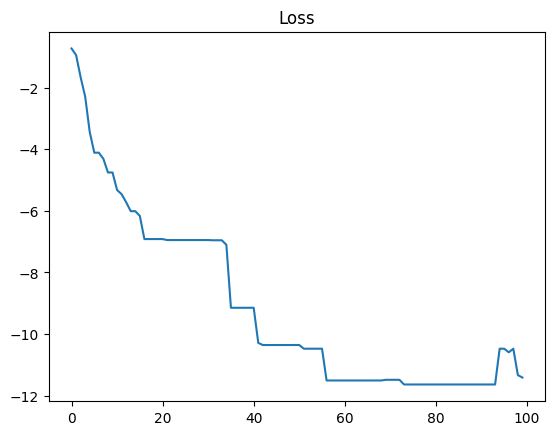

In [511]:
neat_losses = train(100)

In [514]:
config.genome.weight_mutate_power

0.8

In [515]:
params = linear.neat_parameters()
len(params)

4

In [516]:
param_index = np.random.randint(len(params))
param = params[param_index]
param_index

0

In [517]:
linear.neat_modules()[0].mapping

{32782: 0,
 32788: 1,
 36889: 2,
 20525: 3,
 22576: 4,
 30793: 5,
 34905: 6,
 32870: 7,
 28776: 8,
 16506: 9,
 24707: 10,
 37012: 11,
 30869: 12,
 20688: 13,
 16614: 14,
 39142: 15,
 37110: 16,
 28922: 17,
 33054: 18,
 24866: 19,
 20771: 20,
 26916: 21,
 20773: 22,
 37158: 23,
 16681: 24,
 24891: 25,
 20809: 26,
 31049: 27,
 18765: 28,
 33121: 29,
 35171: 30,
 22896: 31,
 37235: 32,
 24948: 33,
 29053: 34,
 24960: 35,
 33163: 36,
 33186: 37,
 29106: 38,
 22970: 39,
 37316: 40,
 29125: 41,
 29133: 42,
 33231: 43,
 27090: 44,
 16858: 45,
 39401: 46,
 35306: 47,
 31221: 48,
 29188: 49,
 18951: 50,
 33289: 51,
 35338: 52,
 27156: 53,
 21020: 54,
 25121: 55,
 16930: 56,
 37414: 57,
 33319: 58,
 16949: 59,
 25172: 60,
 19029: 61,
 16982: 62,
 21087: 63,
 25188: 64,
 37488: 65,
 33401: 66,
 25213: 67,
 29315: 68,
 37512: 69,
 23182: 70,
 17047: 71,
 29337: 72,
 31396: 73,
 25263: 74,
 25266: 75,
 35512: 76,
 25278: 77,
 27329: 78,
 35526: 79,
 17098: 80,
 27342: 81,
 29394: 82,
 21204: 83,
 2

In [518]:
param.data[param_index]

tensor([[[ -9.6865],
         [ -6.5841]],

        [[ -9.5136],
         [ -7.7041]],

        [[  0.4677],
         [ -5.6561]],

        ...,

        [[ -1.9191],
         [-12.5940]],

        [[  0.6668],
         [-15.9767]],

        [[-17.2692],
         [ -7.0470]]], device='cuda:0')

In [519]:
linear.mapping

{32782: 0,
 32788: 1,
 36889: 2,
 20525: 3,
 22576: 4,
 30793: 5,
 34905: 6,
 32870: 7,
 28776: 8,
 16506: 9,
 24707: 10,
 37012: 11,
 30869: 12,
 20688: 13,
 16614: 14,
 39142: 15,
 37110: 16,
 28922: 17,
 33054: 18,
 24866: 19,
 20771: 20,
 26916: 21,
 20773: 22,
 37158: 23,
 16681: 24,
 24891: 25,
 20809: 26,
 31049: 27,
 18765: 28,
 33121: 29,
 35171: 30,
 22896: 31,
 37235: 32,
 24948: 33,
 29053: 34,
 24960: 35,
 33163: 36,
 33186: 37,
 29106: 38,
 22970: 39,
 37316: 40,
 29125: 41,
 29133: 42,
 33231: 43,
 27090: 44,
 16858: 45,
 39401: 46,
 35306: 47,
 31221: 48,
 29188: 49,
 18951: 50,
 33289: 51,
 35338: 52,
 27156: 53,
 21020: 54,
 25121: 55,
 16930: 56,
 37414: 57,
 33319: 58,
 16949: 59,
 25172: 60,
 19029: 61,
 16982: 62,
 21087: 63,
 25188: 64,
 37488: 65,
 33401: 66,
 25213: 67,
 29315: 68,
 37512: 69,
 23182: 70,
 17047: 71,
 29337: 72,
 31396: 73,
 25263: 74,
 25266: 75,
 35512: 76,
 25278: 77,
 27329: 78,
 35526: 79,
 17098: 80,
 27342: 81,
 29394: 82,
 21204: 83,
 2

In [520]:
len(linear.mapping), len(population.genomes), linear.genome_num

(500, 500, 500)

In [521]:
best_key = population.best_genome.key if population.best_genome and population.best_genome.key in population.genomes is not None else None
best_key

32782

In [522]:
train_inp.shape

torch.Size([500, 4, 2])

In [523]:
# accuracy(linear(eval_inp, keys=best_key), eval_out), \
accuracy(linear(train_inp[0].unsqueeze(0), keys=best_key), train_out)

torch.Size([500])


50.0

In [524]:
train_inp.shape

torch.Size([500, 4, 2])

In [525]:
outputs = linear(train_inp[0].unsqueeze(0), keys=best_key)
if best_key is not None:
    outputs = outputs[linear.mapping[best_key]].unsqueeze(0)

In [526]:
outputs.shape

torch.Size([1, 4, 1])

In [527]:
for i, out in enumerate(train_out[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([1.], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [528]:
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([0.9999], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [529]:
import torch.optim as optim
import torch.nn.functional as F

In [550]:
linear2 = nn.Sequential(
    mnn.Transpose(),
    nn.Conv1d(input_dims, embedding, 1, padding=0, bias=bias, device=device, dtype=dtype),
    nn.SiLU(),
    nn.Conv1d(embedding, output_dims, 1, padding=0, bias=bias, device=device, dtype=dtype),
    mnn.Transpose(),
    nn.Sigmoid(),
)
linear2

Sequential(
  (0): Transpose(dim0=-1, dim1=-2)
  (1): Conv1d(2, 64, kernel_size=(1,), stride=(1,))
  (2): SiLU()
  (3): Conv1d(64, 1, kernel_size=(1,), stride=(1,))
  (4): Transpose(dim0=-1, dim1=-2)
  (5): Sigmoid()
)

In [551]:
optimizer = optim.RAdam(linear2.parameters(), 1e-2)

In [552]:
def train2(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    linear2.requires_grad_(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    dims = tuple(range(1, train_out.ndim))
    best_loss = F.mse_loss(linear2(train_inp), train_out)
    best_epoch = -1
    save_state = linear2.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = linear2(train_inp)
            loss = F.mse_loss(test_actv, train_out)
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = linear2.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter()-ts:.2f}s")

    linear2.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    linear2.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

training | loss= 3.6806e-11 | best= 3.6806e-11 | epoch=22999: progress=100% eta=0sec
Finished training in 55.66s


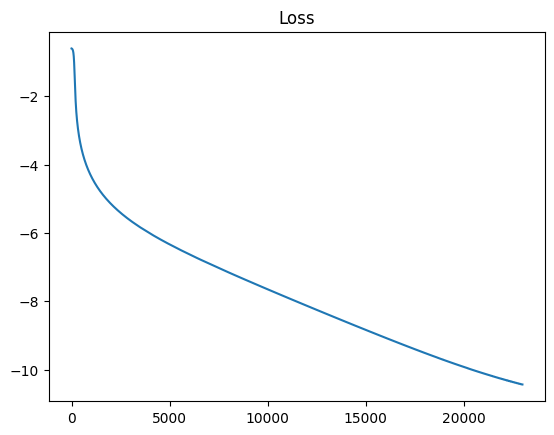

In [553]:
train_losses = train2(23000, checkpoints=1)

In [545]:
min(neat_losses), min(train_losses)

(2.290677630217841e-12, 2.391617502997545e-12)

In [297]:
# linear2.modules_list[0].weights[best_key]

In [298]:
# linear2.modules_list[0].biases[best_key]

In [299]:
outputs = linear2(train_inp) #, keys=best_key)
# if best_key is not None:
#     outputs = outputs[linear2.mapping[best_key]].unsqueeze(0)
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([1.], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [300]:
# plot_attention(att, 0, 0, 3, True, size=(1080, 720))

tensor([[ 0,  1,  2,  ...,  7,  8,  9],
        [10, 11, 12,  ..., 17, 18, 19],
        [20, 21, 22,  ..., 27, 28, 29],
        ...,
        [70, 71, 72,  ..., 77, 78, 79],
        [80, 81, 82,  ..., 87, 88, 89],
        [90, 91, 92,  ..., 97, 98, 99]])

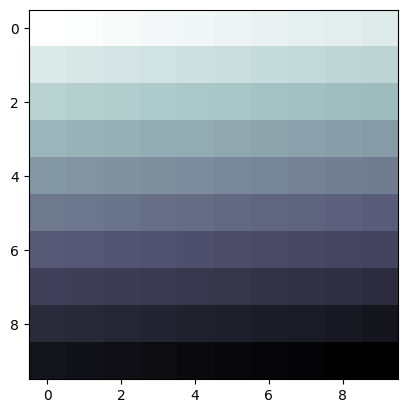

In [301]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)